# Telecom Customer Churn: Factor Identification and Prediction Using Machine Learning

**Project Title:** ტელეკომუნიკაციის მომხმარებელთა გადინების განმაპირობებელი ფაქტორების იდენტიფიცირება და პროგნოზირება მანქანური სწავლების მეთოდებით

**Author:** Mariam Tsintsadze  
**Supervisor:** Prof. Maxim Iavich  
**University:** Caucasus University, School of Technology  

---

## Table of Contents
1. [Import Libraries & Load Data](#1)
2. [Data Cleaning](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Statistical Testing](#4)
5. [Feature Engineering & Preprocessing](#5)
6. [Customer Segmentation](#6)
7. [Model Building (Without SMOTE - Baseline)](#7)
8. [Model Building (With SMOTE)](#8)
9. [Hyperparameter Tuning](#9)
10. [Model Evaluation & Comparison](#10)
11. [Precision-Recall Tradeoff & Threshold Optimization](#11)
12. [SHAP Analysis - Factor Identification](#12)
13. [LIME Validation](#13)
14. [Churn Risk Scoring System](#14)
15. [Business Recommendations](#15)
16. [Pipeline Summary](#16)
17. [Conclusion](#17)

---
<a id="1"></a>
## 1. Import Libraries & Load Data

In [78]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV,
    learning_curve
)

from sklearn.preprocessing import StandardScaler as SC
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier
)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    silhouette_score
)

from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print("All libraries imported successfully.")

All libraries imported successfully.


In [79]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [80]:
print("Dataset Info:")
print("=" * 50)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [81]:
print("\nStatistical Summary (Numerical):")
df.describe()


Statistical Summary (Numerical):


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [82]:
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0


---
<a id="2"></a>
## 2. Data Cleaning

### 2.1 Data Type Verification

In [83]:
print("DATA TYPE VERIFICATION")
print("=" * 60)
print(f"{'Column':<20}{'Current Type':<15}{'Expected Type':<15}{'Status'}")
print("-" * 60)

expected_types = {
    'customerID': 'object', 'gender': 'object', 'SeniorCitizen': 'int64',
    'Partner': 'object', 'Dependents': 'object', 'tenure': 'int64',
    'PhoneService': 'object', 'MultipleLines': 'object', 'InternetService': 'object',
    'OnlineSecurity': 'object', 'OnlineBackup': 'object', 'DeviceProtection': 'object',
    'TechSupport': 'object', 'StreamingTV': 'object', 'StreamingMovies': 'object',
    'Contract': 'object', 'PaperlessBilling': 'object', 'PaymentMethod': 'object',
    'MonthlyCharges': 'float64', 'TotalCharges': 'float64', 'Churn': 'object'
}

issues_found = []
for col in df.columns:
    actual = str(df[col].dtype)
    expected = expected_types.get(col, 'unknown')
    if actual != expected:
        status = "Needs conversion"
        issues_found.append(col)
    else:
        status = "OK"
    print(f"{col:<20}{actual:<15}{expected:<15}{status}")

print("=" * 60)
print(f"\nIssues found: {len(issues_found)}")
if issues_found:
    print(f"  → {issues_found} — needs conversion")

DATA TYPE VERIFICATION
Column              Current Type   Expected Type  Status
------------------------------------------------------------
customerID          object         object         OK
gender              object         object         OK
SeniorCitizen       int64          int64          OK
Partner             object         object         OK
Dependents          object         object         OK
tenure              int64          int64          OK
PhoneService        object         object         OK
MultipleLines       object         object         OK
InternetService     object         object         OK
OnlineSecurity      object         object         OK
OnlineBackup        object         object         OK
DeviceProtection    object         object         OK
TechSupport         object         object         OK
StreamingTV         object         object         OK
StreamingMovies     object         object         OK
Contract            object         object         OK
PaperlessBi

### 2.2 Whitespace & Inconsistency Check in Categorical Columns

In [84]:
print("CATEGORICAL VALUE CONSISTENCY CHECK")
print("=" * 60)

cat_cols_check = df.select_dtypes(include='object').columns.tolist()
inconsistencies = 0

for col in cat_cols_check:
    unique_vals = df[col].unique()
    # Check for leading/trailing whitespace
    whitespace_issues = [v for v in unique_vals if isinstance(v, str) and (v != v.strip())]
    # Check for empty strings
    empty_issues = [v for v in unique_vals if isinstance(v, str) and v.strip() == '']
    
    if whitespace_issues or empty_issues:
        print(f"  ⚠ {col}: Found {len(whitespace_issues)} whitespace issues, {len(empty_issues)} empty values")
        inconsistencies += 1
    else:
        n_unique = len(unique_vals)
        print(f"  ✓ {col}: {n_unique} unique values — clean")

print("=" * 60)
if inconsistencies == 0:
    print("\n All categorical columns are clean — no whitespace or inconsistency issues.")
else:
    print(f"\n {inconsistencies} columns need cleaning.")

CATEGORICAL VALUE CONSISTENCY CHECK
  ✓ customerID: 7043 unique values — clean
  ✓ gender: 2 unique values — clean
  ✓ Partner: 2 unique values — clean
  ✓ Dependents: 2 unique values — clean
  ✓ PhoneService: 2 unique values — clean
  ✓ MultipleLines: 3 unique values — clean
  ✓ InternetService: 3 unique values — clean
  ✓ OnlineSecurity: 3 unique values — clean
  ✓ OnlineBackup: 3 unique values — clean
  ✓ DeviceProtection: 3 unique values — clean
  ✓ TechSupport: 3 unique values — clean
  ✓ StreamingTV: 3 unique values — clean
  ✓ StreamingMovies: 3 unique values — clean
  ✓ Contract: 3 unique values — clean
  ✓ PaperlessBilling: 2 unique values — clean
  ✓ PaymentMethod: 4 unique values — clean
  ⚠ TotalCharges: Found 1 whitespace issues, 1 empty values
  ✓ Churn: 2 unique values — clean

 1 columns need cleaning.


### 2.3 Missing Values Analysis

In [85]:
# Convert TotalCharges to numeric to reveal hidden missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("MISSING VALUES ANALYSIS")
print("=" * 60)
print(f"{'Column':<20}{'Missing':<10}{'% Missing':<12}{'Action'}")
print("-" * 60)

for col in df.columns:
    missing = df[col].isnull().sum()
    pct = missing / len(df) * 100
    if missing > 0:
        action = "Fill with 0 (new customers)"
        print(f"{col:<20}{missing:<10}{pct:<12.2f}{action}")
    
total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print("  No missing values found in any column.")
else:
    print(f"\nTotal missing values: {total_missing}")
    print(f"Affected rows: {df.isnull().any(axis=1).sum()} ({df.isnull().any(axis=1).sum()/len(df)*100:.2f}%)")

print("=" * 60)

# Fix: Fill TotalCharges NaN with 0
print(f"\nCustomers with missing TotalCharges (tenure = 0, new customers):")
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges']].head(11))
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"\nMissing TotalCharges filled with 0. Remaining missing: {df.isnull().sum().sum()}")

MISSING VALUES ANALYSIS
Column              Missing   % Missing   Action
------------------------------------------------------------
TotalCharges        11        0.16        Fill with 0 (new customers)

Total missing values: 11
Affected rows: 11 (0.16%)

Customers with missing TotalCharges (tenure = 0, new customers):
      customerID  tenure  MonthlyCharges
488   4472-LVYGI       0           52.55
753   3115-CZMZD       0           20.25
936   5709-LVOEQ       0           80.85
1082  4367-NUYAO       0           25.75
1340  1371-DWPAZ       0           56.05
3331  7644-OMVMY       0           19.85
3826  3213-VVOLG       0           25.35
4380  2520-SGTTA       0           20.00
5218  2923-ARZLG       0           19.70
6670  4075-WKNIU       0           73.35
6754  2775-SEFEE       0           61.90

Missing TotalCharges filled with 0. Remaining missing: 0


### 2.4 Duplicate Records Check

In [86]:
duplicates = df.duplicated().sum()
duplicate_ids = df['customerID'].duplicated().sum()

print("DUPLICATE RECORDS CHECK")
print("=" * 40)
print(f"  Exact duplicate rows: {duplicates}")
print(f"  Duplicate customerIDs: {duplicate_ids}")

if duplicates == 0 and duplicate_ids == 0:
    print("\n No duplicates found — each row represents a unique customer.")
else:
    print(f"\n Found duplicates — removing...")
    df = df.drop_duplicates()

DUPLICATE RECORDS CHECK
  Exact duplicate rows: 0
  Duplicate customerIDs: 0

 No duplicates found — each row represents a unique customer.


### 2.5 Outlier Detection (IQR Method)

In [87]:
numerical_cols_outlier = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("OUTLIER ANALYSIS (IQR Method)")
print("=" * 70)
print(f"{'Feature':<18}{'Q1':<10}{'Q3':<10}{'IQR':<10}{'Lower':<10}{'Upper':<10}{'Outliers':<10}")
print("-" * 70)

for col in numerical_cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:<18}{Q1:<10.1f}{Q3:<10.1f}{IQR:<10.1f}{lower:<10.1f}{upper:<10.1f}{outliers:<10}")

print("=" * 70)
if outliers == 0:
    print("\n No outliers detected in numerical features.")
else:
    print(f"\nTotal outliers detected across all numerical features: {outliers}")

OUTLIER ANALYSIS (IQR Method)
Feature           Q1        Q3        IQR       Lower     Upper     Outliers  
----------------------------------------------------------------------
tenure            9.0       55.0      46.0      -60.0     124.0     0         
MonthlyCharges    35.5      89.8      54.3      -46.0     171.4     0         
TotalCharges      398.6     3786.6    3388.0    -4683.5   8868.7    0         

 No outliers detected in numerical features.


### 2.6 Data Cleaning Summary

DATA CLEANING SUMMARY

  1. Dataset shape: (7043, 21)
  2. Total missing values: 0 (fixed)
  3. Duplicates removed: 0
  4. Outliers: None found
  5. Type corrections: TotalCharges (object → float64)
  6. Whitespace issues: None found

✓ Dataset is clean and ready for feature engineering.

---
<a id="3"></a>
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

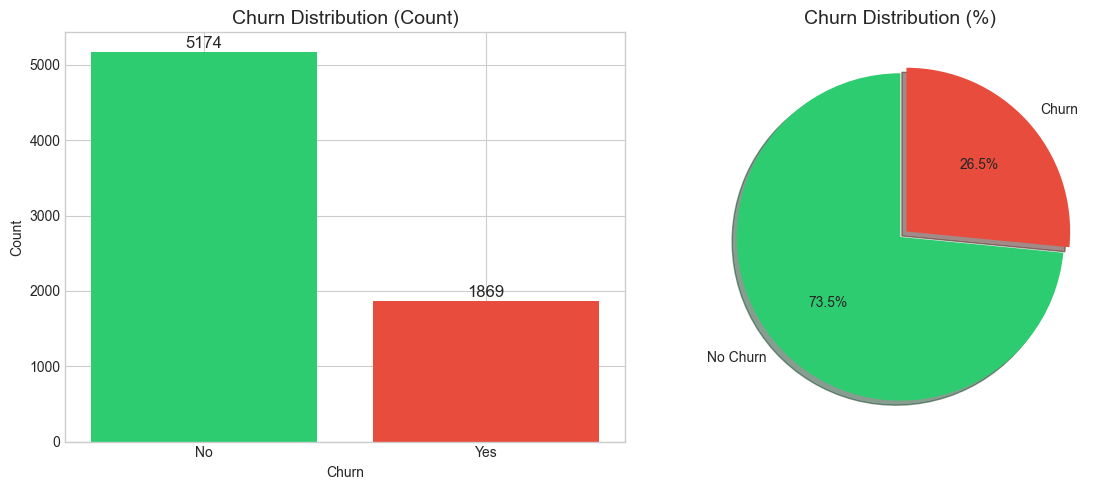

No Churn: 5174 (73.5%)
Churn: 1869 (26.5%)


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.05), shadow=True, startangle=90)
axes[1].set_title('Churn Distribution (%)', fontsize=14)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"No Churn: {churn_counts['No']} ({churn_counts['No']/len(df)*100:.1f}%)")
print(f"Churn: {churn_counts['Yes']} ({churn_counts['Yes']/len(df)*100:.1f}%)")

### 3.2 Demographic Analysis

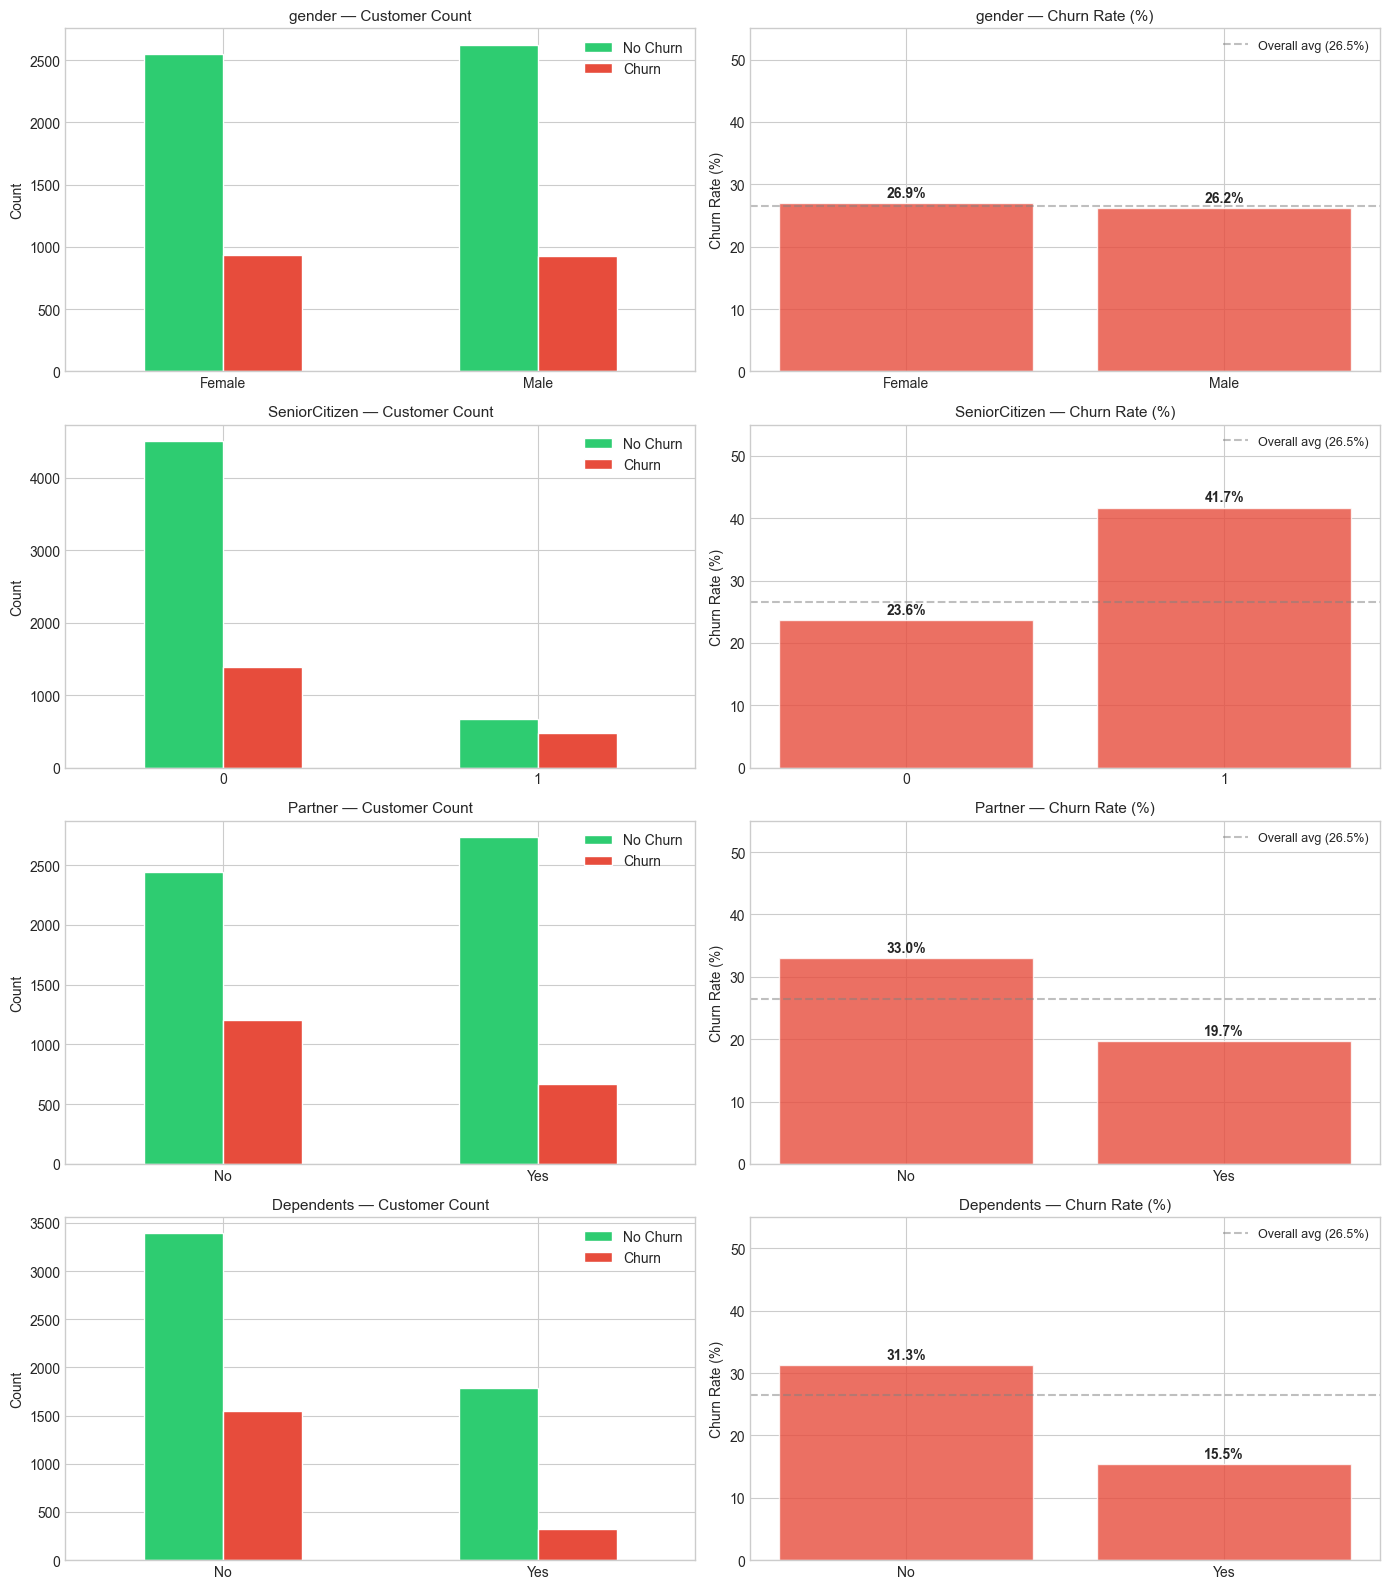

In [89]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

for idx, col in enumerate(demo_cols):
    # Left: Count distribution
    ax_count = axes[idx, 0]
    counts = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    counts.plot(kind='bar', ax=ax_count, color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax_count.set_title(f'{col} — Customer Count', fontsize=11)
    ax_count.set_ylabel('Count')
    ax_count.set_xlabel('')
    ax_count.legend(['No Churn', 'Churn'], loc='upper right')
    ax_count.tick_params(axis='x', rotation=0)
    
    # Right: Churn rate
    ax_rate = axes[idx, 1]
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
    bars = ax_rate.bar(range(len(churn_rate)), churn_rate.values, 
                       color='#e74c3c', edgecolor='white', alpha=0.8)
    ax_rate.set_xticks(range(len(churn_rate)))
    ax_rate.set_xticklabels(churn_rate.index)
    ax_rate.set_title(f'{col} — Churn Rate (%)', fontsize=11)
    ax_rate.set_ylabel('Churn Rate (%)')
    ax_rate.set_ylim(0, 55)
    ax_rate.axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Overall avg (26.5%)')
    ax_rate.legend(fontsize=9)
    for j, v in enumerate(churn_rate.values):
        ax_rate.text(j, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Service-Related Analysis

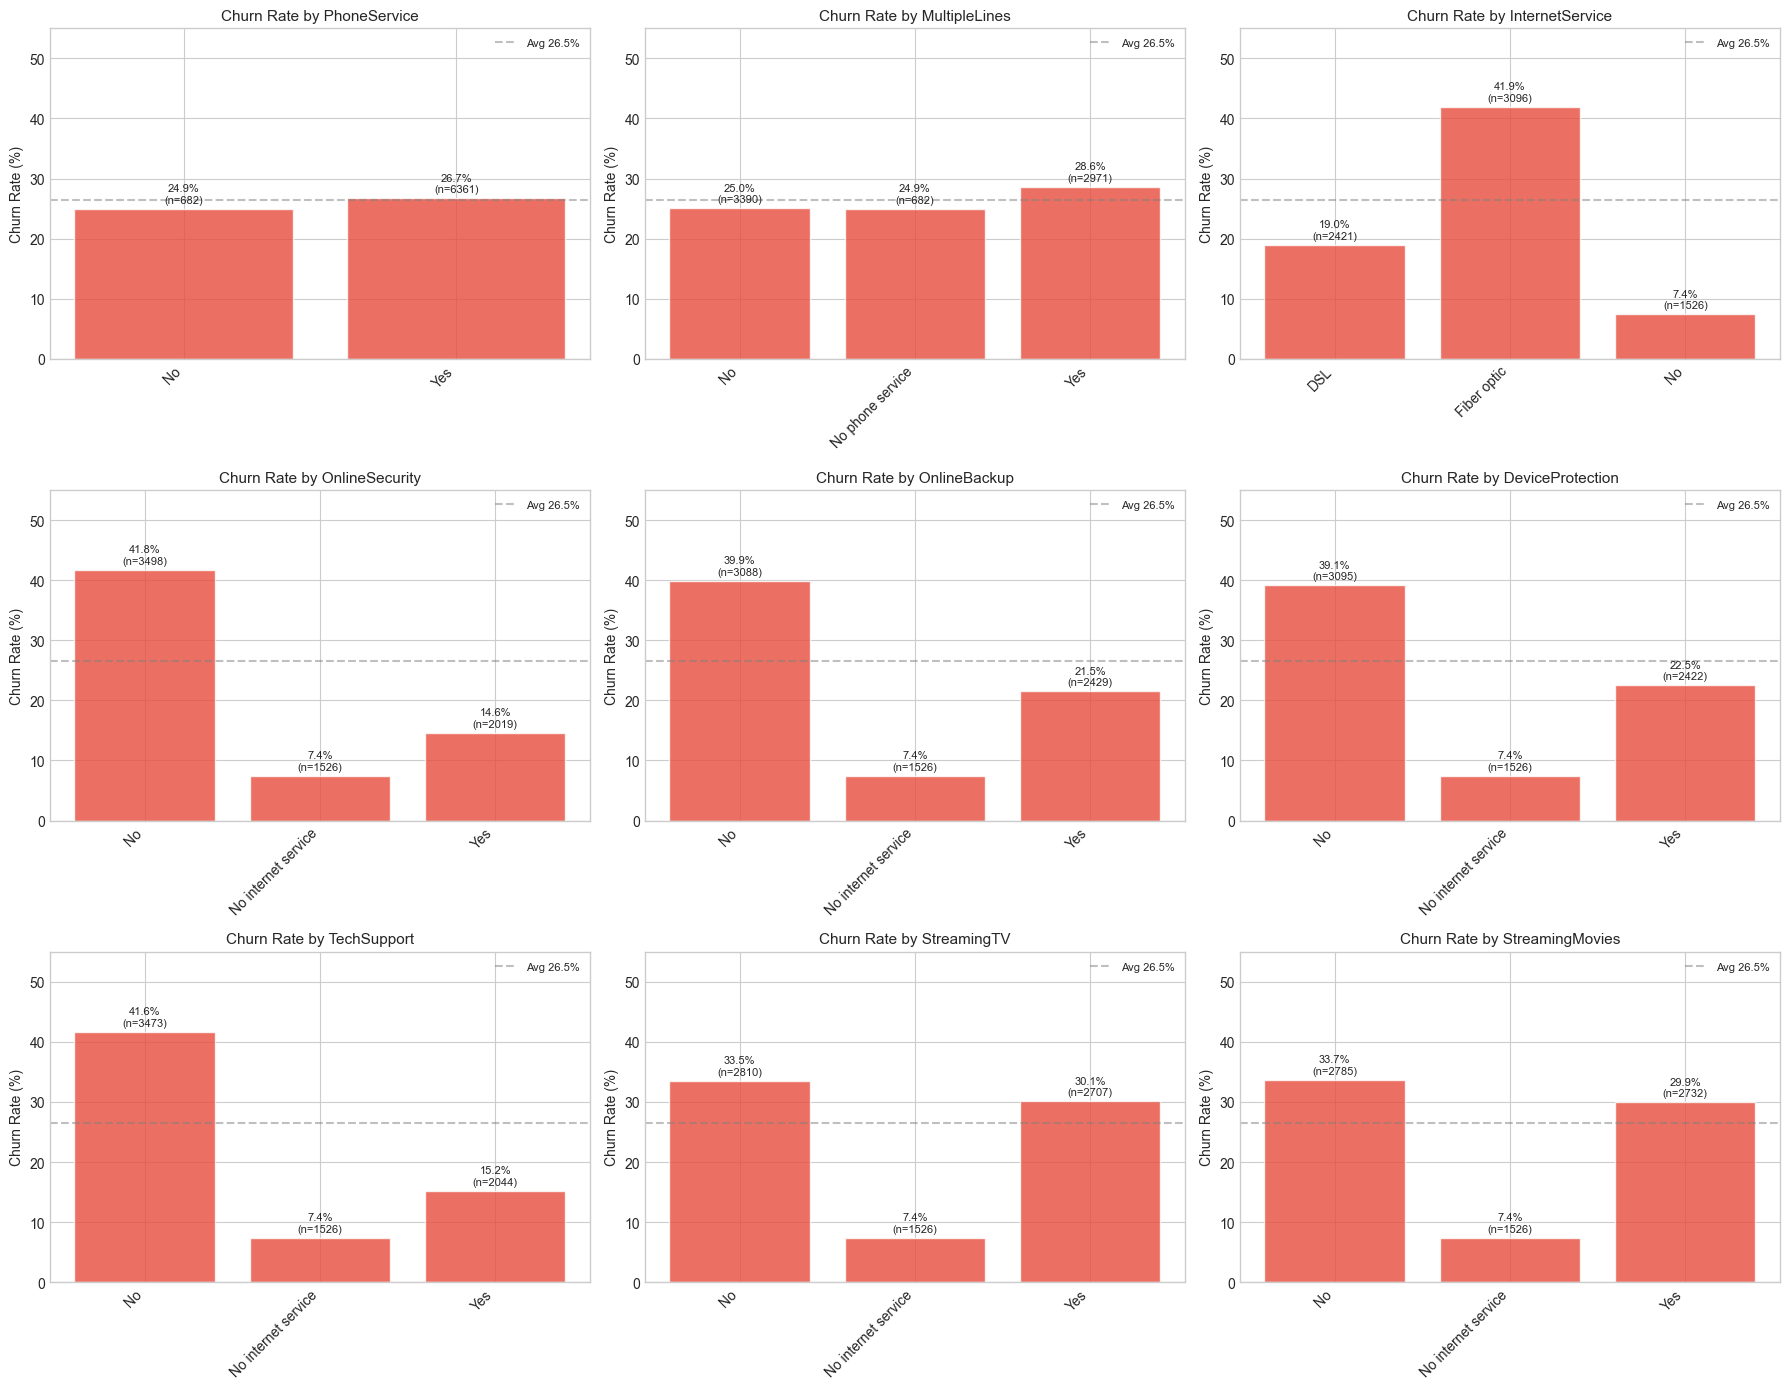

In [90]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
    group_size = df.groupby(col).size()
    
    bars = axes[i].bar(range(len(churn_rate)), churn_rate.values, 
                       color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=45, ha='right')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
    axes[i].set_ylim(0, 55)
    axes[i].axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Avg 26.5%')
    axes[i].legend(fontsize=8)
    # Show rate AND count (n=) on each bar
    for j, (rate, n) in enumerate(zip(churn_rate.values, group_size.values)):
        axes[i].text(j, rate + 1, f'{rate:.1f}%\n(n={n})', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('service_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Contract and Billing Analysis

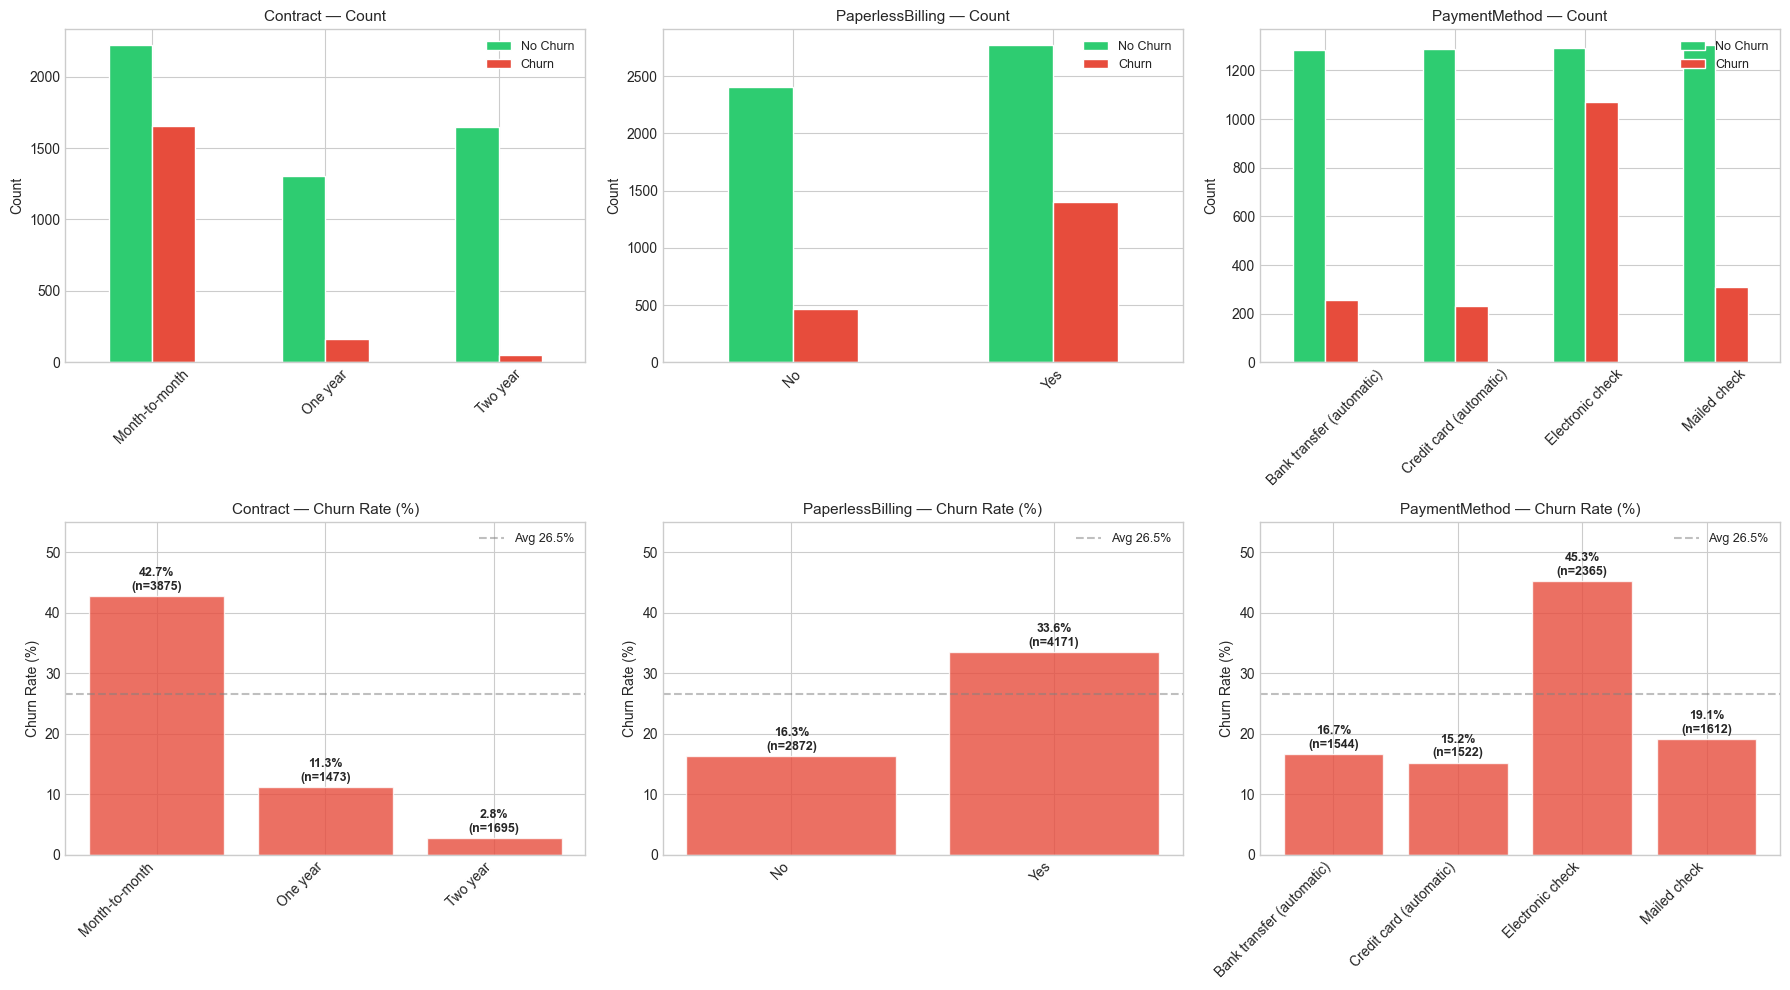

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

billing_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

for idx, col in enumerate(billing_cols):
    # Top row: Counts
    ax_count = axes[0, idx]
    counts = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    counts.plot(kind='bar', ax=ax_count, color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax_count.set_title(f'{col} — Count', fontsize=11)
    ax_count.set_ylabel('Count')
    ax_count.set_xlabel('')
    ax_count.legend(['No Churn', 'Churn'], fontsize=9)
    ax_count.tick_params(axis='x', rotation=45)
    
    # Bottom row: Churn rate
    ax_rate = axes[1, idx]
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
    group_size = df.groupby(col).size()
    bars = ax_rate.bar(range(len(churn_rate)), churn_rate.values, 
                       color='#e74c3c', edgecolor='white', alpha=0.8)
    ax_rate.set_xticks(range(len(churn_rate)))
    ax_rate.set_xticklabels(churn_rate.index, rotation=45, ha='right')
    ax_rate.set_ylabel('Churn Rate (%)')
    ax_rate.set_title(f'{col} — Churn Rate (%)', fontsize=11)
    ax_rate.set_ylim(0, 55)
    ax_rate.axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Avg 26.5%')
    ax_rate.legend(fontsize=9)
    for j, (rate, n) in enumerate(zip(churn_rate.values, group_size.values)):
        ax_rate.text(j, rate + 1, f'{rate:.1f}%\n(n={n})', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('contract_billing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Numerical Features Analysis

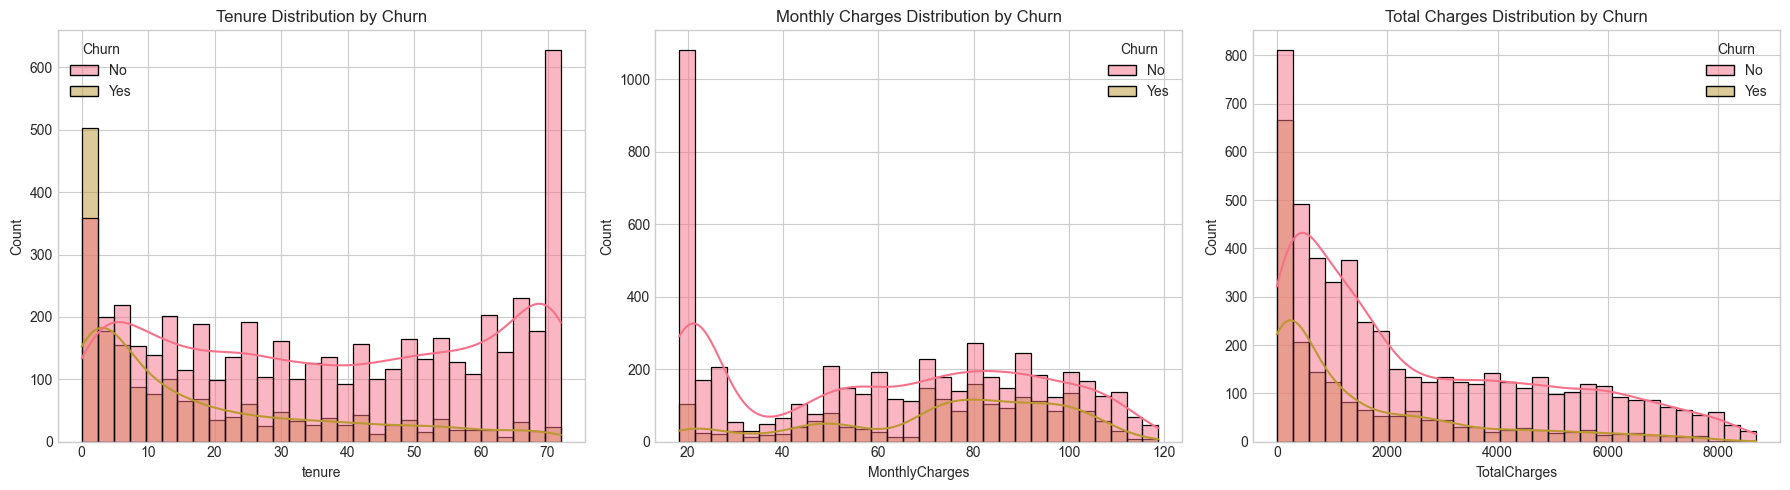

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0], bins=30)
axes[0].set_title('Tenure Distribution by Churn')

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1], bins=30)
axes[1].set_title('Monthly Charges Distribution by Churn')

sns.histplot(data=df.dropna(subset=['TotalCharges']), x='TotalCharges', hue='Churn', kde=True, ax=axes[2], bins=30)
axes[2].set_title('Total Charges Distribution by Churn')

plt.tight_layout()
plt.savefig('numerical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [93]:
# bins start at -1 (not 0) to make the first interval (-1, 12],
# which correctly includes tenure=0 customers (new customers with no billing yet).
# Starting at 0 would create (0, 12] which silently drops tenure=0 as NaN.
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72],
                            labels=['0-12', '13-24', '25-48', '49-72'])

# Verify no NaN tenure groups (would indicate customers were dropped)
nan_groups = df['tenure_group'].isnull().sum()
if nan_groups == 0:
    print("\n Tenure groups assigned successfully to all customers.")
else:
    print(f"\n Warning: {nan_groups} customers have no tenure group assigned.")
    print("Check tenure values outside the defined bins.")

churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
print("\nChurn Rate by Tenure Group:")
print(churn_by_tenure.to_string())
print("\nGroup '0-12' represents the highest-risk period for customer churn.")


 Tenure groups assigned successfully to all customers.

Churn Rate by Tenure Group:
tenure_group
0-12     47.438243
13-24    28.710938
25-48    20.388959
49-72     9.513176

Group '0-12' represents the highest-risk period for customer churn.


### 3.6 Correlation Analysis

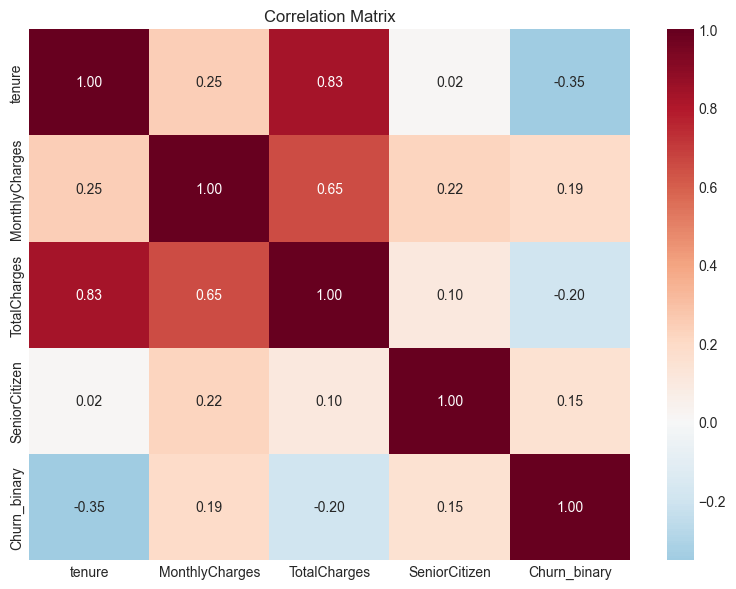

In [94]:
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
corr_matrix = df_corr[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 EDA Key Insights Summary

Based on the exploratory analysis above, the following key observations emerge:

1. **Class Imbalance**: The dataset is imbalanced — only ~26.5% of customers churned. This needs to be addressed during modeling to avoid bias toward the majority class.

2. **Contract Type is Critical**: Month-to-month customers churn at dramatically higher rates than those on 1-year or 2-year contracts. Long-term contracts act as a strong retention mechanism.

3. **Tenure Matters**: New customers (0-12 months) have the highest churn rate. Churn decreases significantly as tenure increases, suggesting the first year is the most vulnerable period.

4. **Security/Support Services Reduce Churn**: Customers without Online Security or Tech Support show noticeably higher churn rates. These services appear to increase customer "stickiness."

5. **Payment Method Signal**: Electronic check users churn more than those using automatic payment methods (credit card, bank transfer). This may indicate less commitment or engagement.

6. **Higher Monthly Charges = Higher Churn**: Customers paying more per month are more likely to leave, especially when they don't perceive value from additional services.

---
<a id="4"></a>
## 4. Statistical Testing

To validate our EDA observations statistically, we perform:
- **Chi-Square Test** for categorical features (is the association with churn statistically significant?)
- **Independent Samples T-Test** for numerical features (is the mean difference significant?)

### 4.1 Chi-Square Test for Categorical Features

In [95]:
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                        'PhoneService', 'MultipleLines', 'InternetService',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies',
                        'Contract', 'PaperlessBilling', 'PaymentMethod']

chi2_results = []
for col in categorical_features:
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    chi2_results.append({
        'Feature': col,
        'Chi-Square': round(chi2, 2),
        'P-Value': p_value,
        'Significant (p<0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi-Square', ascending=False)
print("CHI-SQUARE TEST RESULTS")
print("=" * 70)
print(f"{'Feature':<20}{'Chi-Square':<15}{'P-Value':<15}{'Significant?'}")
print("-" * 70)
for _, row in chi2_df.iterrows():
    sig = "Yes" if row['Significant (p<0.05)'] == 'Yes' else "No"
    print(f"{row['Feature']:<20}{row['Chi-Square']:<15.2f}{row['P-Value']:<15.6f}{sig}")
print("=" * 70)
print(f"\nSignificant features: {chi2_df[chi2_df['Significant (p<0.05)']=='Yes'].shape[0]}/{len(chi2_df)}")

CHI-SQUARE TEST RESULTS
Feature             Chi-Square     P-Value        Significant?
----------------------------------------------------------------------
Contract            1184.60        0.000000       Yes
OnlineSecurity      850.00         0.000000       Yes
TechSupport         828.20         0.000000       Yes
InternetService     732.31         0.000000       Yes
PaymentMethod       648.14         0.000000       Yes
OnlineBackup        601.81         0.000000       Yes
DeviceProtection    558.42         0.000000       Yes
StreamingMovies     375.66         0.000000       Yes
StreamingTV         374.20         0.000000       Yes
PaperlessBilling    258.28         0.000000       Yes
Dependents          189.13         0.000000       Yes
SeniorCitizen       159.43         0.000000       Yes
Partner             158.73         0.000000       Yes
MultipleLines       11.33          0.003464       Yes
PhoneService        0.92           0.338783       No
gender              0.48         

### 4.2 T-Test for Numerical Features

In [96]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

churners = df[df['Churn'] == 'Yes']
non_churners = df[df['Churn'] == 'No']

print("INDEPENDENT SAMPLES T-TEST RESULTS")
print("=" * 80)
print(f"{'Feature':<18}{'Mean (Churn)':<15}{'Mean (No Churn)':<17}{'T-Stat':<12}{'P-Value':<12}{'Sig?'}")
print("-" * 80)

for col in numerical_features:
    churn_vals = churners[col].dropna()
    no_churn_vals = non_churners[col].dropna()
    t_stat, p_value = ttest_ind(churn_vals, no_churn_vals)
    sig = "Yes" if p_value < 0.05 else "No"
    print(f"{col:<18}{churn_vals.mean():<15.2f}{no_churn_vals.mean():<17.2f}{t_stat:<12.2f}{p_value:<12.6f}{sig}")

print("=" * 80)
print("\n→ All numerical features show statistically significant differences between churners and non-churners (p < 0.05).")

INDEPENDENT SAMPLES T-TEST RESULTS
Feature           Mean (Churn)   Mean (No Churn)  T-Stat      P-Value     Sig?
--------------------------------------------------------------------------------
tenure            17.98          37.57            -31.58      0.000000    Yes
MonthlyCharges    74.44          61.27            16.54       0.000000    Yes
TotalCharges      1531.80        2549.91          -16.98      0.000000    Yes

→ All numerical features show statistically significant differences between churners and non-churners (p < 0.05).


---
<a id="5"></a>
## 5. Feature Engineering & Preprocessing

In [97]:
df['ChargePerService'] = df['MonthlyCharges'] / (
    # (df['PhoneService'] == 'Yes').astype(int) + 
    (df['InternetService'] != 'No').astype(int) + 
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int) +
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int) + 1
)

df['NumServices'] = (
    # (df['PhoneService'] == 'Yes').astype(int) +
    (df['InternetService'] != 'No').astype(int) +
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int) +
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

df['HasSecuritySupport'] = ((df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')).astype(int)
df['HasStreaming'] = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype(int)

# EDA showed customers with tenure <= 12 months have the highest churn rate.
# Encoding this directly as a binary flag gives the model a clear signal
# for the highest-risk tenure group.
df['IsNewCustomer'] = (df['tenure'] <= 12).astype(int)

# A customer who is BOTH month-to-month AND new is dramatically more likely
# to churn than either condition alone. This interaction feature captures
# that compound risk directly.
df['HighRiskProfile'] = (
    (df['Contract'] == 'Month-to-month') & (df['tenure'] <= 12)
).astype(int)


new_features = ['NumServices', 'HasSecuritySupport', 'HasStreaming',
                'ChargePerService', 'IsNewCustomer', 'HighRiskProfile']

print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"{'Feature':<22}{'Description'}")
print("-" * 60)
print(f"{'NumServices':<22}Total number of active services")
print(f"{'HasSecuritySupport':<22}Has Online Security or Tech Support")
print(f"{'HasStreaming':<22}Has Streaming TV or Movies")
print(f"{'ChargePerService':<22}Monthly charge per meaningful service")
print(f"{'IsNewCustomer':<22}Tenure <= 12 months (highest risk group)")
print(f"{'HighRiskProfile':<22}Month-to-month AND tenure <= 12")
print("=" * 60)

print(f"\nDistribution of new binary features:")
for feat in ['IsNewCustomer', 'HighRiskProfile']:
    count = df[feat].sum()
    pct = df[feat].mean() * 100
    churn_rate = df[df[feat] == 1]['Churn'].apply(
        lambda x: 1 if x == 'Yes' else 0).mean() * 100
    print(f"  {feat}: {count} customers ({pct:.1f}%) — churn rate: {churn_rate:.1f}%")

print(f"\nDataset shape after feature engineering: {df.shape}")


FEATURE ENGINEERING SUMMARY
Feature               Description
------------------------------------------------------------
NumServices           Total number of active services
HasSecuritySupport    Has Online Security or Tech Support
HasStreaming          Has Streaming TV or Movies
ChargePerService      Monthly charge per meaningful service
IsNewCustomer         Tenure <= 12 months (highest risk group)
HighRiskProfile       Month-to-month AND tenure <= 12

Distribution of new binary features:
  IsNewCustomer: 2186 customers (31.0%) — churn rate: 47.4%
  HighRiskProfile: 1994 customers (28.3%) — churn rate: 51.4%

Dataset shape after feature engineering: (7043, 28)


### 5.2 Feature Selection (Dropping Non-Significant Features)

Based on the Chi-Square test results (Section 4), `gender` showed **no statistically significant association** with churn (p > 0.05). Keeping non-significant features adds noise without adding predictive value. We make a data-driven decision to remove it.

In [98]:
# Two features failed the chi-square test (p > 0.05):
# - gender:       p = 0.487 — male vs female churn rate virtually identical
# - PhoneService: p = 0.339 — phone subscribers vs non-subscribers show
#                 no significant churn rate difference
# Both are dropped as data-driven feature selection decisions.

# This is a data-driven feature selection decision
print(f"Before dropping: {df.shape[1]} columns")
df.drop(['gender', 'PhoneService'], axis=1, inplace=True)
print(f"After dropping:  {df.shape[1]} columns")

print("\nFeature Selection Justification:")
print("  DROPPED — gender:")
print("    Chi-Square p = 0.487 (NOT significant)")
print("    Male churn: ~26.2% vs Female: ~26.9% — virtually identical")
print()
print("  DROPPED — PhoneService:")
print("    Chi-Square p = 0.339 (NOT significant)")
print("    Phone subscribers vs non-subscribers show no meaningful churn difference\n")
print("  KEPT — all 14 remaining features significant at p < 0.05")
print(f"\nFeature selection complete: {df.shape[1]} features retained.")

Before dropping: 28 columns
After dropping:  26 columns

Feature Selection Justification:
  DROPPED — gender:
    Chi-Square p = 0.487 (NOT significant)
    Male churn: ~26.2% vs Female: ~26.9% — virtually identical

  DROPPED — PhoneService:
    Chi-Square p = 0.339 (NOT significant)
    Phone subscribers vs non-subscribers show no meaningful churn difference

  KEPT — all 14 remaining features significant at p < 0.05

Feature selection complete: 26 features retained.


In [99]:
df_model = df.drop(['customerID', 'tenure_group'], axis=1)
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
print(f"\nDataset shape after encoding: {df_encoded.shape}")

Categorical columns to encode: ['Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Dataset shape after encoding: (7043, 35)


### 5.3 Multicollinearity Check (VIF)

Variance Inflation Factor (VIF) measures how much a feature is correlated with other features. VIF > 10 indicates problematic multicollinearity that could inflate model coefficients and make interpretation unreliable.

In [100]:
numerical_features_vif = df_encoded.drop('Churn', axis=1).astype(float)

# VIF > 10 indicates problematic multicollinearity
# VIF > 5 warrants attention
vif_data = pd.DataFrame()
vif_data['Feature'] = numerical_features_vif.columns
vif_data['VIF'] = [variance_inflation_factor(numerical_features_vif.values, i) 
                   for i in range(numerical_features_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("=" * 55)
print(f"{'Feature':<35}{'VIF':<10}{'Status'}")
print("-" * 55)
for _, row in vif_data.iterrows():
    if row['VIF'] > 10:
        status = "High"
    elif row['VIF'] > 5:
        status = "Moderate"
    else:
        status = "OK"
    print(f"{row['Feature']:<35}{row['VIF']:<10.2f}{status}")
print("=" * 55)

high_vif = vif_data[vif_data['VIF'] > 10]
print(f"\nFeatures with VIF > 10: {len(high_vif)}")
if len(high_vif) > 0:
    print("Note: Some multicollinearity exists (e.g., TotalCharges correlates with tenure).")
    print("This is expected and acceptable because:")
    print("  1. Random Forest (our final model) is completely immune to multicollinearity")
    print("     — random feature subsampling at each split naturally decorrelates features")
    print("  2. TreeExplainer (SHAP) handles correlated features correctly for RF")
    print("  3. High VIF features like TotalCharges and tenure carry genuine business")
    print("     signal — removing them would reduce model interpretability")
else:
    print("All features have acceptable VIF levels.")

VARIANCE INFLATION FACTOR (VIF) ANALYSIS
Feature                            VIF       Status
-------------------------------------------------------
StreamingMovies_No internet serviceinf       High
InternetService_No                 inf       High
StreamingTV_No internet service    inf       High
TechSupport_No internet service    inf       High
DeviceProtection_No internet serviceinf       High
OnlineBackup_No internet service   inf       High
OnlineSecurity_No internet service inf       High
NumServices                        24719.12  High
MonthlyCharges                     879.99    High
OnlineBackup_Yes                   556.55    High
DeviceProtection_Yes               553.53    High
StreamingMovies_Yes                487.26    High
StreamingTV_Yes                    482.40    High
TechSupport_Yes                    464.80    High
OnlineSecurity_Yes                 459.73    High
InternetService_Fiber optic        148.36    High
MultipleLines_No phone service     34.89     High


### 5.4 Train-Test Split and Scaling

In [101]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Features for training: {X.shape[1]}")

# Stratified split ensures equal churn ratio in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nChurn rate in training: {y_train.mean()*100:.1f}%")
print(f"Churn rate in testing: {y_test.mean()*100:.1f}%")

# StandardScaler applied for Logistic Regression.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

Features for training: 34
Training set: 5634 samples
Testing set: 1409 samples

Churn rate in training: 26.5%
Churn rate in testing: 26.5%


### 5.5 Handling Class Imbalance with SMOTE

The dataset has ~73.5% non-churners vs ~26.5% churners. We apply SMOTE (Synthetic Minority Over-sampling Technique) to the training set only.

In [102]:
# Apply SMOTE (Synthetic Minority Over-sampling Technique)
# Only applied to training data to prevent data leakage
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote_scaled = pd.DataFrame(
    scaler.transform(X_train_smote), 
    columns=X_train_smote.columns, 
    index=X_train_smote.index
)

print(f"Before SMOTE:")
print(f"  Training set: {X_train.shape[0]} | Churn=0: {(y_train==0).sum()} | Churn=1: {(y_train==1).sum()}")
print(f"\nAfter SMOTE:")
print(f"  Training set: {X_train_smote.shape[0]} | Churn=0: {(y_train_smote==0).sum()} | Churn=1: {(y_train_smote==1).sum()}")
print("\nClasses are now balanced in the training set.")

Before SMOTE:
  Training set: 5634 | Churn=0: 4139 | Churn=1: 1495

After SMOTE:
  Training set: 8278 | Churn=0: 4139 | Churn=1: 4139

Classes are now balanced in the training set.


---
## 6. Customer Segmentation Analysis (K-Means Clustering)

After engineering features, we perform unsupervised analysis to discover natural customer segments. This provides additional business insight and reveals which customer profiles are most vulnerable to churn.

Beyond prediction, we use unsupervised learning (K-Means) to discover natural customer segments. This reveals which customer profiles are most vulnerable to churn and enables segment-specific retention strategies.

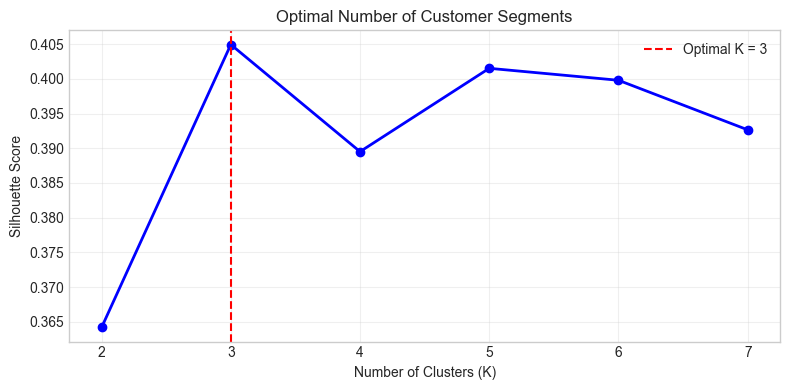

Optimal number of clusters: 3 (silhouette = 0.4050)

Clustering features used: ['tenure', 'MonthlyCharges', 'NumServices', 'Contract_num', 'InternetService_num']


In [103]:
# ── Feature selection for clustering ─────────────────────────────────────────
# approach: include the strongest churn predictors so clusters
# reflect real behavioral differences, not just spending levels.

cluster_features = [
    'tenure',           # How long they've been a customer
    'MonthlyCharges',   # How much they pay per month
    'NumServices',      # How many services they use
]

# Encode contract type numerically for clustering
# Month-to-month=0, One year=1, Two year=2 (ordinal — longer = more committed)
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract_num'] = df['Contract'].map(contract_map)

# Encode internet service for clustering
# No=0, DSL=1, Fiber optic=2
internet_map = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
df['InternetService_num'] = df['InternetService'].map(internet_map)

cluster_features_extended = cluster_features + ['Contract_num', 'InternetService_num']
X_cluster = df[cluster_features_extended].copy()

# NOTE: We use a separate scaler here — scaler_cluster — so that
# the main pipeline scaler (fitted on X_train) is not affected.
scaler_cluster = SC()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# ── Find optimal K using silhouette score ─────────────────────────────────────
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

optimal_k = K_range[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_scores, 'bo-', linewidth=2)
plt.axvline(x=optimal_k, color='red', linestyle='--',
            label=f'Optimal K = {optimal_k}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Optimal Number of Customer Segments')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal number of clusters: {optimal_k} "
      f"(silhouette = {max(silhouette_scores):.4f})")
print(f"\nClustering features used: {cluster_features_extended}")

In [104]:
# ── Fit K-Means with optimal K ────────────────────────────────────────────────
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print("CUSTOMER SEGMENTATION ANALYSIS")
print("=" * 85)
print(f"{'Cluster':<10}{'Size':<8}{'Avg Tenure':<13}{'Avg Monthly$':<14}"
      f"{'Avg Services':<14}{'Contract Score':<16}{'Churn Rate'}")
print("-" * 85)

for cluster in range(optimal_k):
    mask = df['Cluster'] == cluster
    size = mask.sum()
    avg_tenure     = df.loc[mask, 'tenure'].mean()
    avg_monthly    = df.loc[mask, 'MonthlyCharges'].mean()
    avg_services   = df.loc[mask, 'NumServices'].mean()
    avg_contract   = df.loc[mask, 'Contract_num'].mean()
    churn_rate     = (df.loc[mask, 'Churn'] == 'Yes').mean() * 100
    print(f"  {cluster:<8}{size:<8}{avg_tenure:<13.1f}{avg_monthly:<14.1f}"
          f"{avg_services:<14.1f}{avg_contract:<16.2f}{churn_rate:.1f}%")

print("=" * 85)
print("\nContract Score guide: 0 = Month-to-month, 1 = One year, 2 = Two year")

CUSTOMER SEGMENTATION ANALYSIS
Cluster   Size    Avg Tenure   Avg Monthly$  Avg Services  Contract Score  Churn Rate
-------------------------------------------------------------------------------------
  0       1590    30.7         21.7          0.1           1.07            7.5%
  1       2108    58.0         86.8          5.1           1.39            11.1%
  2       3345    17.1         71.4          2.7           0.07            45.3%

Contract Score guide: 0 = Month-to-month, 1 = One year, 2 = Two year


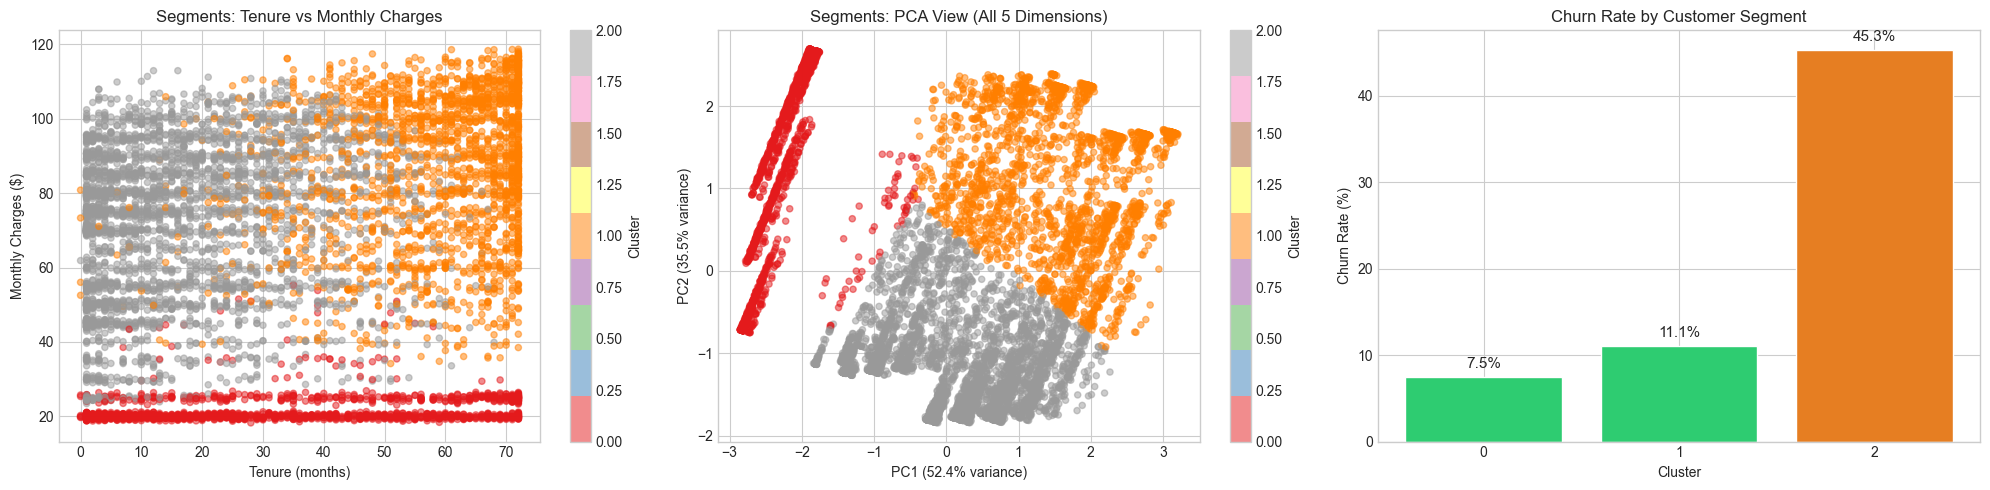


PCA variance explained: PC1=52.4%, PC2=35.5%, Total=87.9%
Higher total = PCA plot is a more faithful representation of cluster separation.


In [105]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Plot 1: Tenure vs Monthly Charges (2D slice) ──────────────────────────────
scatter = axes[0].scatter(
    df['tenure'], df['MonthlyCharges'],
    c=df['Cluster'], cmap='Set1', alpha=0.5, s=20
)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_title('Segments: Tenure vs Monthly Charges')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# ── Plot 2: PCA — shows ALL 5 clustering dimensions reduced to 2D ─────────────
# This is more honest than a 2D scatter because it captures variance
# from all 5 features, not just 2 of them.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
var_explained = pca.explained_variance_ratio_ * 100

scatter2 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['Cluster'], cmap='Set1', alpha=0.5, s=20
)
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
axes[1].set_title('Segments: PCA View (All 5 Dimensions)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# ── Plot 3: Churn rate by cluster ─────────────────────────────────────────────
cluster_churn = df.groupby('Cluster')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
colors = [
    '#2ecc71' if c < 20 else
    '#f39c12' if c < 35 else
    '#e67e22' if c < 50 else
    '#e74c3c'
    for c in cluster_churn.values
]
axes[2].bar(range(optimal_k), cluster_churn.values,
            color=colors, edgecolor='white')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_title('Churn Rate by Customer Segment')
axes[2].set_xticks(range(optimal_k))
for i, v in enumerate(cluster_churn.values):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPCA variance explained: PC1={var_explained[0]:.1f}%, "
      f"PC2={var_explained[1]:.1f}%, "
      f"Total={sum(var_explained):.1f}%")
print("Higher total = PCA plot is a more faithful representation of cluster separation.")

In [106]:
# ── Segment profiles derived from data, not hardcoded thresholds ──────────────
# Previous version used arbitrary thresholds (avg_tenure < 20, avg_monthly > 70)
# which could break if K changes. This version ranks clusters by churn rate
# and assigns profiles based on their actual characteristics.

print("\nSEGMENT-SPECIFIC RETENTION STRATEGIES")
print("=" * 75)

# Build a summary per cluster
cluster_summary = []
for cluster in range(optimal_k):
    mask = df['Cluster'] == cluster
    cluster_summary.append({
        'cluster':      cluster,
        'size':         mask.sum(),
        'churn_rate':   (df.loc[mask, 'Churn'] == 'Yes').mean() * 100,
        'avg_tenure':   df.loc[mask, 'tenure'].mean(),
        'avg_monthly':  df.loc[mask, 'MonthlyCharges'].mean(),
        'avg_services': df.loc[mask, 'NumServices'].mean(),
        'avg_contract': df.loc[mask, 'Contract_num'].mean(),
    })

# Sort by churn rate descending so highest-risk cluster is always first
cluster_summary.sort(key=lambda x: x['churn_rate'], reverse=True)

for rank, seg in enumerate(cluster_summary):
    # Profile is derived from actual cluster stats, not fixed cutoffs
    if seg['churn_rate'] >= 40:
        profile  = "Critical Risk"
        strategy = ("Prioritize retention efforts. Consider contract upgrade "
                    "incentives, targeted discounts, and proactive outreach.")
    elif seg['churn_rate'] >= 25:
        profile  = "High Risk"
        strategy = ("Proactive email/SMS campaign. Offer 10% discount or "
                    "free trial of Tech Support / Online Security.")
    elif seg['churn_rate'] >= 15:
        profile  = "Moderate Risk"
        strategy = ("Monthly check-in program. Gentle upsell to annual "
                    "contract with loyalty bonus at 12-month mark.")
    else:
        profile  = "Low Risk / Loyal"
        strategy = ("VIP recognition program. Exclusive early-access deals. "
                    "Focus on upselling premium services.")

    print(f"\n  Cluster {seg['cluster']} — {profile} (Rank #{rank+1} by churn risk)")
    print(f"    Size:          {seg['size']} customers")
    print(f"    Churn Rate:    {seg['churn_rate']:.1f}%")
    print(f"    Avg Tenure:    {seg['avg_tenure']:.0f} months")
    print(f"    Avg Monthly$:  ${seg['avg_monthly']:.0f}")
    print(f"    Avg Services:  {seg['avg_services']:.1f}")
    print(f"    Contract Score:{seg['avg_contract']:.2f} "
          f"(0=month-to-month, 2=two-year)")
    print(f"    Strategy:      {strategy}")

print("\n" + "=" * 75)
print("\nProfiles ranked by actual churn rate — strategies scale with risk level.")
print("Contract score close to 0 = predominantly month-to-month customers.")

# ── Drop temporary columns used only for clustering ───────────────────────────
# Cluster, Contract_num, InternetService_num are dropped here because:
#   1. Cluster membership was derived from the same data the model trains on
#      — including it as a feature would be circular / data leakage.
#   2. Contract_num and InternetService_num are already encoded by
#      get_dummies in section 5.2, so they'd be duplicated.
df.drop(['Cluster', 'Contract_num', 'InternetService_num'],
        axis=1, inplace=True)

print(f"\nTemporary clustering columns dropped.")
print(f"  Dataset shape restored: {df.shape}")


SEGMENT-SPECIFIC RETENTION STRATEGIES

  Cluster 2 — Critical Risk (Rank #1 by churn risk)
    Size:          3345 customers
    Churn Rate:    45.3%
    Avg Tenure:    17 months
    Avg Monthly$:  $71
    Avg Services:  2.7
    Contract Score:0.07 (0=month-to-month, 2=two-year)
    Strategy:      Prioritize retention efforts. Consider contract upgrade incentives, targeted discounts, and proactive outreach.

  Cluster 1 — Low Risk / Loyal (Rank #2 by churn risk)
    Size:          2108 customers
    Churn Rate:    11.1%
    Avg Tenure:    58 months
    Avg Monthly$:  $87
    Avg Services:  5.1
    Contract Score:1.39 (0=month-to-month, 2=two-year)
    Strategy:      VIP recognition program. Exclusive early-access deals. Focus on upselling premium services.

  Cluster 0 — Low Risk / Loyal (Rank #3 by churn risk)
    Size:          1590 customers
    Churn Rate:    7.5%
    Avg Tenure:    31 months
    Avg Monthly$:  $22
    Avg Services:  0.1
    Contract Score:1.07 (0=month-to-month, 

---
<a id="7"></a>
## 7. Model Building (Without SMOTE - Baseline)

First, we train models WITHOUT SMOTE to establish a baseline. This allows us to demonstrate the impact of handling class imbalance.

In [107]:
# Baseline models (no SMOTE)
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_scaled, y_train)
lr_base_pred = lr_base.predict(X_test_scaled)
lr_base_prob = lr_base.predict_proba(X_test_scaled)[:, 1]

rf_base = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, 
                                  min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
rf_base_pred = rf_base.predict(X_test)
rf_base_prob = rf_base.predict_proba(X_test)[:, 1]

xgb_base = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, 
                          subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)
xgb_base_pred = xgb_base.predict(X_test)
xgb_base_prob = xgb_base.predict_proba(X_test)[:, 1]

print("BASELINE RESULTS (Without SMOTE)")
print("=" * 80)
print(f"{'Model':<25}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}{'AUC'}")
print("-" * 80)
for name, pred, prob in [('Logistic Regression', lr_base_pred, lr_base_prob),
                          ('Random Forest', rf_base_pred, rf_base_prob),
                          ('XGBoost', xgb_base_pred, xgb_base_prob)]:
    print(f"{name:<25}{accuracy_score(y_test, pred):<12.4f}{precision_score(y_test, pred):<12.4f}"
          f"{recall_score(y_test, pred):<12.4f}{f1_score(y_test, pred):<12.4f}{roc_auc_score(y_test, prob):.4f}")
print("=" * 80)

BASELINE RESULTS (Without SMOTE)
Model                    Accuracy    Precision   Recall      F1          AUC
--------------------------------------------------------------------------------
Logistic Regression      0.8006      0.6566      0.5214      0.5812      0.8421
Random Forest            0.8048      0.6749      0.5107      0.5814      0.8423
XGBoost                  0.7913      0.6299      0.5187      0.5689      0.8323


Note: Recall for churners is relatively low - the models miss many actual churners.

---
<a id="8"></a>
## 8. Model Building (With SMOTE)

Now we train the same models on SMOTE-balanced data to improve detection of churners.

In [108]:
# SMOTE models
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote_scaled, y_train_smote)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5,
                                   min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

xgb_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("SMOTE RESULTS (With Class Balancing)")
print("=" * 80)
print(f"{'Model':<25}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}{'AUC'}")
print("-" * 80)
for name, pred, prob in [('Logistic Regression', lr_pred, lr_prob),
                          ('Random Forest', rf_pred, rf_prob),
                          ('XGBoost', xgb_pred, xgb_prob)]:
    print(f"{name:<25}{accuracy_score(y_test, pred):<12.4f}{precision_score(y_test, pred):<12.4f}"
          f"{recall_score(y_test, pred):<12.4f}{f1_score(y_test, pred):<12.4f}{roc_auc_score(y_test, prob):.4f}")
print("=" * 80)

SMOTE RESULTS (With Class Balancing)
Model                    Accuracy    Precision   Recall      F1          AUC
--------------------------------------------------------------------------------
Logistic Regression      0.7764      0.5770      0.5909      0.5839      0.8318
Random Forest            0.7715      0.5588      0.6604      0.6054      0.8378
XGBoost                  0.7800      0.5870      0.5775      0.5822      0.8254


SMOTE significantly improved Recall — models now catch more churners.

Although XGBoost achieved the highest accuracy (78.0%), Random Forest delivered the strongest overall performance with the highest Recall (66.0%), F1-score (0.605), and ROC-AUC (0.838). Since the primary objective is to identify customers at risk of churning, Random Forest was selected as the final model.

### 8.1 Before vs After SMOTE Comparison

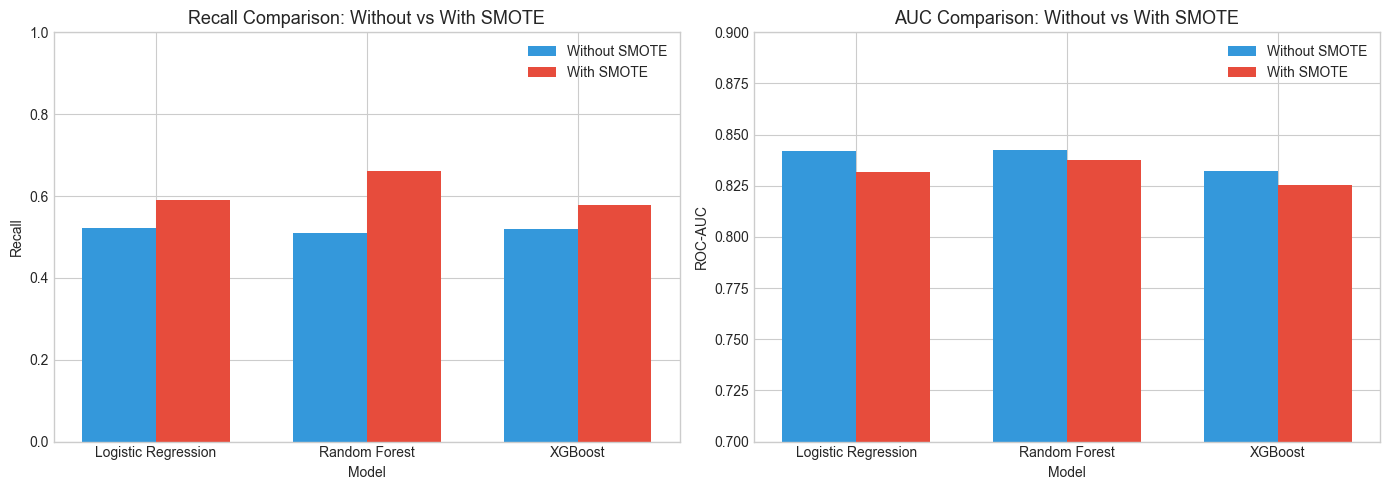

In [109]:
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Recall (No SMOTE)': [recall_score(y_test, lr_base_pred), recall_score(y_test, rf_base_pred), recall_score(y_test, xgb_base_pred)],
    'Recall (With SMOTE)': [recall_score(y_test, lr_pred), recall_score(y_test, rf_pred), recall_score(y_test, xgb_pred)],
    'AUC (No SMOTE)': [roc_auc_score(y_test, lr_base_prob), roc_auc_score(y_test, rf_base_prob), roc_auc_score(y_test, xgb_base_prob)],
    'AUC (With SMOTE)': [roc_auc_score(y_test, lr_prob), roc_auc_score(y_test, rf_prob), roc_auc_score(y_test, xgb_prob)]
}

comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(3)
width = 0.35
axes[0].bar(x - width/2, comp_df['Recall (No SMOTE)'], width, label='Without SMOTE', color='#3498db')
axes[0].bar(x + width/2, comp_df['Recall (With SMOTE)'], width, label='With SMOTE', color='#e74c3c')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Recall')
axes[0].set_title('Recall Comparison: Without vs With SMOTE', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comp_df['Model'])
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(x - width/2, comp_df['AUC (No SMOTE)'], width, label='Without SMOTE', color='#3498db')
axes[1].bar(x + width/2, comp_df['AUC (With SMOTE)'], width, label='With SMOTE', color='#e74c3c')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('AUC Comparison: Without vs With SMOTE', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comp_df['Model'])
axes[1].legend()
axes[1].set_ylim(0.7, 0.9)

plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# print("\nKey Insight: SMOTE improves Recall (catching churners) while maintaining strong AUC.")
# print("This is critical for the business — a missed churner is a lost customer.")

SMOTE substantially improved Recall across all models, increasing the ability to identify customers at risk of churn. Although ROC-AUC decreased slightly, the reduction was minimal. This trade-off is acceptable because, in churn prediction, failing to identify a potential churner is generally more costly than contacting a customer who would have stayed. Therefore, the SMOTE-balanced models provide greater business value.

---
<a id="9"></a>
## 9. Hyperparameter Tuning (XGBoost with RandomizedSearchCV)

To maximize model performance, we perform hyperparameter tuning on XGBoost.

In [110]:
param_distributions = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb_tuner = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_distributions,
    n_iter=50,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Running hyperparameter tuning (50 iterations, 5-fold CV)...")
xgb_tuner.fit(X_train_smote, y_train_smote)

print(f"\nBest Parameters Found:")
for param, value in xgb_tuner.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV ROC-AUC: {xgb_tuner.best_score_:.4f}")

# Replace with tuned model
xgb_model = xgb_tuner.best_estimator_
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"\nTuned XGBoost - Test Set:")
print(classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn']))

Running hyperparameter tuning (50 iterations, 5-fold CV)...

Best Parameters Found:
  subsample: 0.7
  n_estimators: 200
  min_child_weight: 1
  max_depth: 7
  learning_rate: 0.05
  gamma: 0.1
  colsample_bytree: 1.0

Best CV ROC-AUC: 0.9343

Tuned XGBoost - Test Set:
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



Hyperparameter tuning substantially improved the cross-validation ROC-AUC of XGBoost, achieving a best CV score of 0.935. However, the improvement did not fully translate to the independent test set, where performance remained comparable to the untuned model. Random Forest continued to provide the strongest overall balance of Recall, F1-score, and ROC-AUC, making it the preferred model for churn prediction.


---
<a id="10"></a>
## 10. Model Evaluation & Comparison

### 10.1 Final Metrics Comparison

In [111]:
results = {}
models = {
    'Logistic Regression': (lr_pred, lr_prob),
    'Random Forest': (rf_pred, rf_prob),
    'XGBoost (Tuned)': (xgb_pred, xgb_prob)
}

for name, (pred, prob) in models.items():
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    }

results_df = pd.DataFrame(results).T.round(4)
print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON TABLE (All with SMOTE)")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)


FINAL MODEL COMPARISON TABLE (All with SMOTE)
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7764     0.5770  0.5909    0.5839   0.8318
Random Forest          0.7715     0.5588  0.6604    0.6054   0.8378
XGBoost (Tuned)        0.7828     0.5919  0.5856    0.5887   0.8268


Although Tuned XGBoost achieved the highest Accuracy (78.3%) and Precision (59.2%), Random Forest delivered the strongest overall performance with the highest Recall (66.0%), F1-score (0.605), and ROC-AUC (0.838). Since the primary objective is to identify customers at risk of churn, Random Forest was selected as the final model for deployment and business decision-making.

### Model Selection - Explicit Number Comparison

In [112]:
print("FINAL MODEL SELECTION JUSTIFICATION")
print("=" * 80)
print(f"\n{'Metric':<18}{'Log. Regression':<20}{'Random Forest':<20}{'XGBoost (Tuned)'}")
print("-" * 80)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for metric in metrics:
    vals = [results['Logistic Regression'][metric],
            results['Random Forest'][metric],
            results['XGBoost (Tuned)'][metric]]
    best_idx = vals.index(max(vals))
    row = f"{metric:<18}"
    for i, v in enumerate(vals):
        marker = " ◄ best" if i == best_idx else ""
        row += f"{v:<20.4f}" if marker == "" else f"{str(round(v,4)) + marker:<20}"
    print(row)

print("=" * 80)

FINAL MODEL SELECTION JUSTIFICATION

Metric            Log. Regression     Random Forest       XGBoost (Tuned)
--------------------------------------------------------------------------------
Accuracy          0.7764              0.7715              0.7828 ◄ best       
Precision         0.5770              0.5588              0.5919 ◄ best       
Recall            0.5909              0.6604 ◄ best       0.5856              
F1-Score          0.5839              0.6054 ◄ best       0.5887              
ROC-AUC           0.8318              0.8378 ◄ best       0.8268              


### Final Model Selection: Random Forest

Based on the evaluation results, Random Forest was selected as the final prediction model for the following reasons:

1. **Highest ROC-AUC** (0.8378) — Best overall ability to distinguish churners from non-churners across different classification thresholds.
2. **Highest Recall** (0.6604) — Identifies the largest proportion of customers who are actually at risk of churning, which is critical for retention efforts.
3. **Highest F1-Score** (0.6054) — Provides the best balance between Recall and Precision among all evaluated models.
4. **Robustness to Multicollinearity** — Random Forest is far less sensitive to correlated features than linear models, allowing the use of engineered features without negatively affecting predictive performance.
5. **No Feature Scaling Required** — Tree-based models are scale-invariant, resulting in a simpler and more robust production pipeline.
6. **Reliable Explainability** — Tree-based SHAP explanations can be used to interpret feature importance and understand the drivers of customer churn.

Although **XGBoost (Tuned)** achieved the highest Accuracy (0.7828) and Precision (0.5919), its Recall (0.5856) and ROC-AUC (0.8268) were lower than those of Random Forest. Since the primary objective of churn prediction is to identify as many potential churners as possible, Recall and ROC-AUC were prioritized over Accuracy.

Therefore, **Random Forest provides the strongest overall business value and was selected as the final model for deployment and decision-making.**

### 10.2 ROC Curves

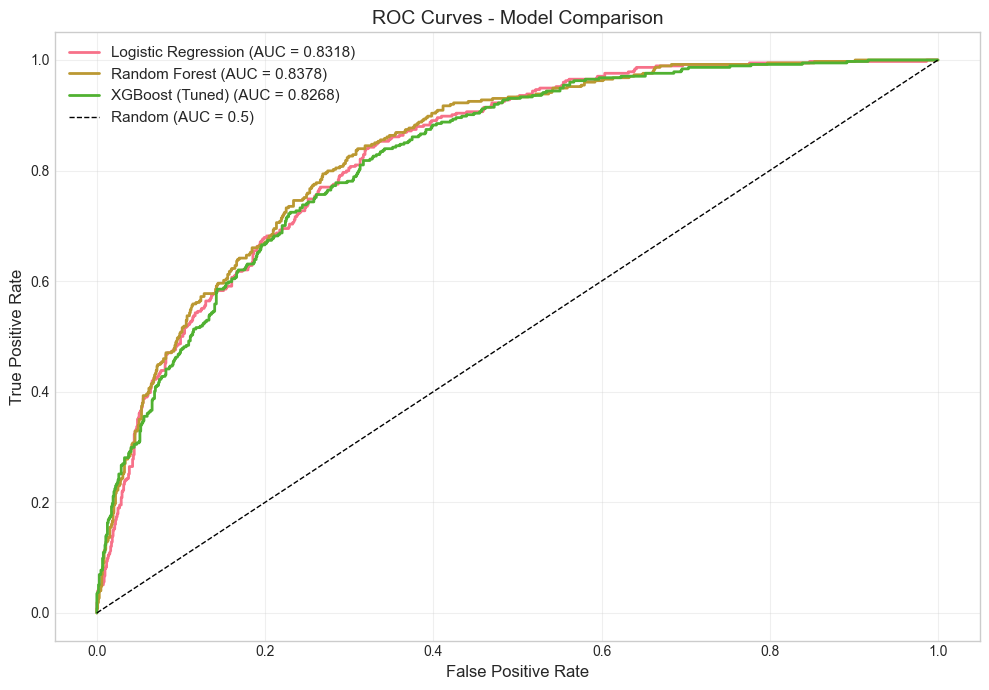

In [113]:
plt.figure(figsize=(10, 7))

for name, (pred, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.3 Confusion Matrices

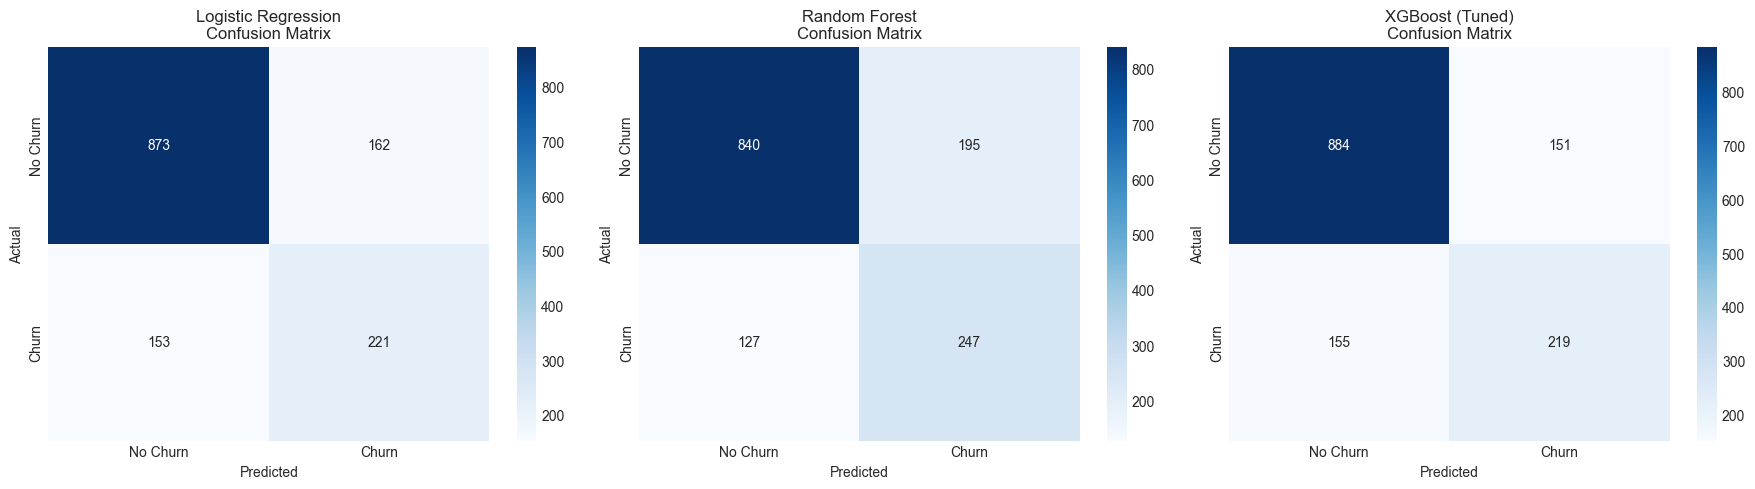

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, (pred, prob)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'], 
                yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.5 Learning Curves

Learning curves show how model performance changes with increasing training data. They help diagnose:
- **Overfitting**: training score high, validation score low (large gap)
- **Underfitting**: both scores low
- **Good fit**: both scores converge at a high value

/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X 

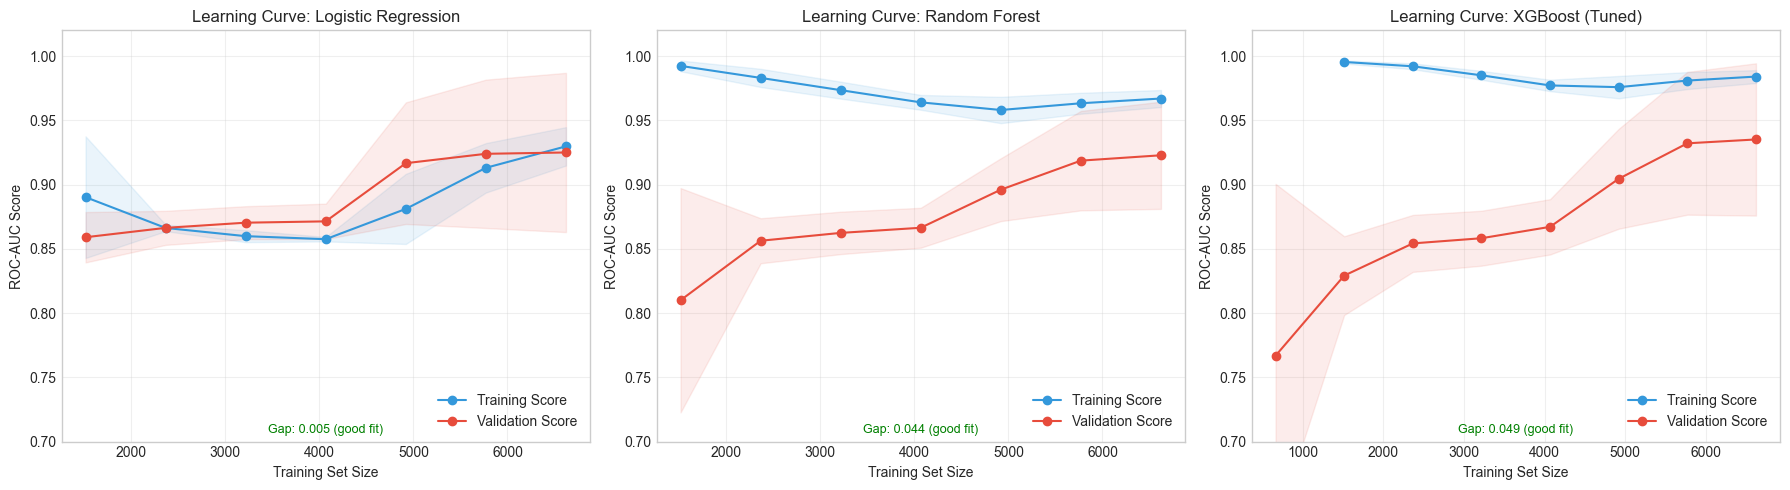

Learning Curve Analysis:
  - Small gap between training and validation = no significant overfitting
  - Scores plateau = adding more data won't help much (model has learned the pattern)
  - Both curves at high level = good model capacity for this problem


In [115]:
# Learning curves diagnose overfitting (gap) vs underfitting (low scores)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

learning_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42), X_train_smote_scaled, y_train_smote),
    ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42), X_train_smote, y_train_smote),
    ('XGBoost (Tuned)', xgb_model, X_train_smote, y_train_smote)
]

for i, (name, model, X_data, y_data) in enumerate(learning_models):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_data, y_data, 
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    axes[i].plot(train_sizes, train_mean, 'o-', color='#3498db', label='Training Score')
    axes[i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#3498db')
    axes[i].plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation Score')
    axes[i].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#e74c3c')
    
    axes[i].set_xlabel('Training Set Size')
    axes[i].set_ylabel('ROC-AUC Score')
    axes[i].set_title(f'Learning Curve: {name}', fontsize=12)
    axes[i].legend(loc='lower right')
    axes[i].set_ylim(0.7, 1.02)
    axes[i].grid(True, alpha=0.3)
    
    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.05:
        axes[i].text(0.5, 0.02, f'Gap: {gap:.3f} (slight overfitting)', transform=axes[i].transAxes, 
                     ha='center', fontsize=9, color='orange')
    else:
        axes[i].text(0.5, 0.02, f'Gap: {gap:.3f} (good fit)', transform=axes[i].transAxes,
                     ha='center', fontsize=9, color='green')

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Learning Curve Analysis:")
print("  - Small gap between training and validation = no significant overfitting")
print("  - Scores plateau = adding more data won't help much (model has learned the pattern)")
print("  - Both curves at high level = good model capacity for this problem")

### 10.4 Cross-Validation

In [116]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation Results (Recall) — SMOTE applied inside each fold:")
print("-" * 65)

cv_pipelines = [
    ('Logistic Regression', ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])),
    ('Random Forest', ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
    ])),
    ('XGBoost (Tuned)', ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', xgb_model)
    ]))
]

for name, pipeline in cv_pipelines:
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall')
    print(f"{name:25s}: Mean = {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\nSMOTE is applied inside each fold — no synthetic samples leak into validation sets.")

5-Fold Cross-Validation Results (Recall) — SMOTE applied inside each fold:
-----------------------------------------------------------------
Logistic Regression      : Mean = 0.6054 (+/- 0.0284)
Random Forest            : Mean = 0.6615 (+/- 0.0216)
XGBoost (Tuned)          : Mean = 0.5786 (+/- 0.0177)

SMOTE is applied inside each fold — no synthetic samples leak into validation sets.


To obtain an unbiased estimate of model performance, SMOTE was incorporated inside an imbalanced-learn pipeline and applied separately within each training fold during 5-fold cross-validation. This prevents data leakage by ensuring that synthetic observations are generated only from the training portion of each fold, while validation folds remain untouched. Recall was used as the evaluation metric because correctly identifying potential churners is the primary business objective.

---
## 10.6 Stacking Ensemble (Advanced Model Combination)

A Stacking Classifier combines multiple base models by training a meta-learner on their predictions. This typically outperforms any individual model because it leverages the strengths of each base estimator while compensating for their weaknesses.

In [117]:
# Define base models (Level 0)
base_estimators = [
    ('lr', Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))])),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, 
                           random_state=42, eval_metric='logloss'))
]

# Meta-learner (Level 1) - uses base model predictions as features
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

print("Training Stacking Ensemble (3 base models + meta-learner)...")
stacking_model.fit(X_train_smote, y_train_smote)

stack_pred = stacking_model.predict(X_test)
stack_prob = stacking_model.predict_proba(X_test)[:, 1]

print(f"\nStacking Ensemble Results:")
print("=" * 50)
print(f"  Accuracy:  {accuracy_score(y_test, stack_pred):.4f}")
print(f"  Precision: {precision_score(y_test, stack_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, stack_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, stack_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, stack_prob):.4f}")

# Compare with best individual model
print(f"\nComparison with best individual model (Random Forest):")
print(f"  RF Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"  Stack Accuracy:  {accuracy_score(y_test, stack_pred):.4f}")

print(f"  RF Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"  Stack Precision: {precision_score(y_test, stack_pred):.4f}")

print(f"  RF Recall:     {recall_score(y_test, rf_pred):.4f}")
print(f"  Stack Recall:  {recall_score(y_test, stack_pred):.4f}")

print(f"  RF F1:         {f1_score(y_test, rf_pred):.4f}")
print(f"  Stack F1:      {f1_score(y_test, stack_pred):.4f}")

print(f"  RF ROC-AUC:    {roc_auc_score(y_test, rf_prob):.4f}")
print(f"  Stack ROC-AUC: {roc_auc_score(y_test, stack_prob):.4f}")


Training Stacking Ensemble (3 base models + meta-learner)...


/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in 


Stacking Ensemble Results:
  Accuracy:  0.7821
  Precision: 0.5823
  Recall:    0.6337
  F1-Score:  0.6069
  ROC-AUC:   0.8398

Comparison with best individual model (Random Forest):
  RF Accuracy:  0.7715
  Stack Accuracy:  0.7821
  RF Precision: 0.5588
  Stack Precision: 0.5823
  RF Recall:     0.6604
  Stack Recall:  0.6337
  RF F1:         0.6054
  Stack F1:      0.6069
  RF ROC-AUC:    0.8378
  Stack ROC-AUC: 0.8398


/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/mariam.tsintsadze/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in 

Although Stacking achieved slightly higher Accuracy, Precision, and ROC-AUC, Random Forest maintained the highest Recall. Since the primary business objective is to identify as many potential churners as possible, Recall was considered the most important metric. Therefore, Random Forest was selected as the final model.

---
<a id="11"></a>
## 11. Precision-Recall Tradeoff & Threshold Optimization

The default threshold of 0.5 may not be optimal for the business. A missed churner (false negative) costs the company a lost customer, while a false alarm (false positive) only costs a retention offer. We optimize the threshold to minimize business cost.

### 11.1 Precision-Recall Curve

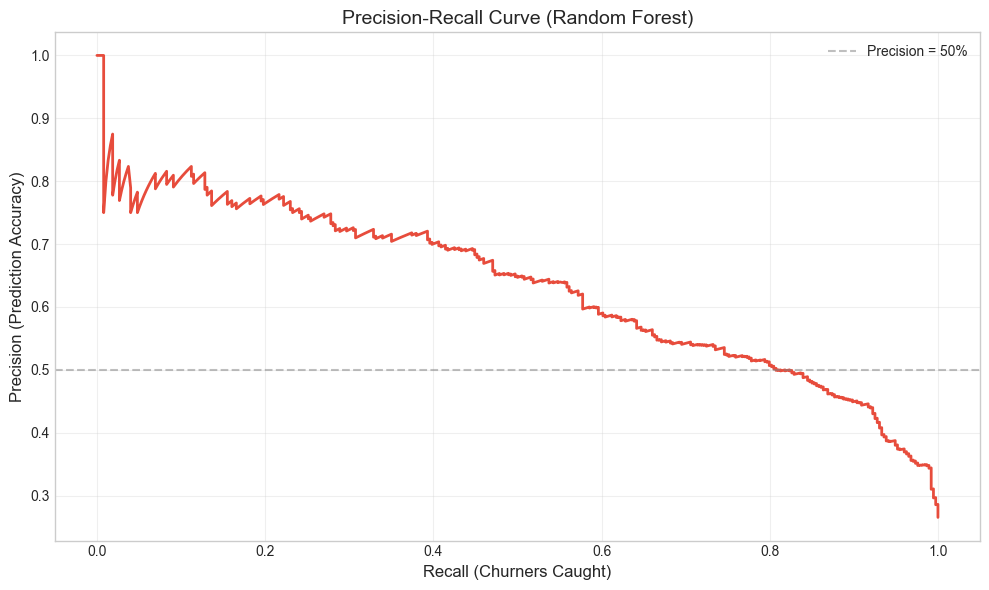

In [118]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, rf_prob)

plt.figure(figsize=(10, 6))
plt.plot(recall_vals, precision_vals, linewidth=2, color='#e74c3c')
plt.xlabel('Recall (Churners Caught)', fontsize=12)
plt.ylabel('Precision (Prediction Accuracy)', fontsize=12)
plt.title('Precision-Recall Curve (Random Forest)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Precision = 50%')
plt.legend()
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.2 Business Cost-Based Threshold Optimization

**Assumptions:**
- Cost of missing a churner (False Negative): $500 (lost revenue)
- Cost of unnecessary retention offer (False Positive): $100 (wasted discount)
- Cost of correctly identifying a churner (True Positive): -$400 (saved customer)

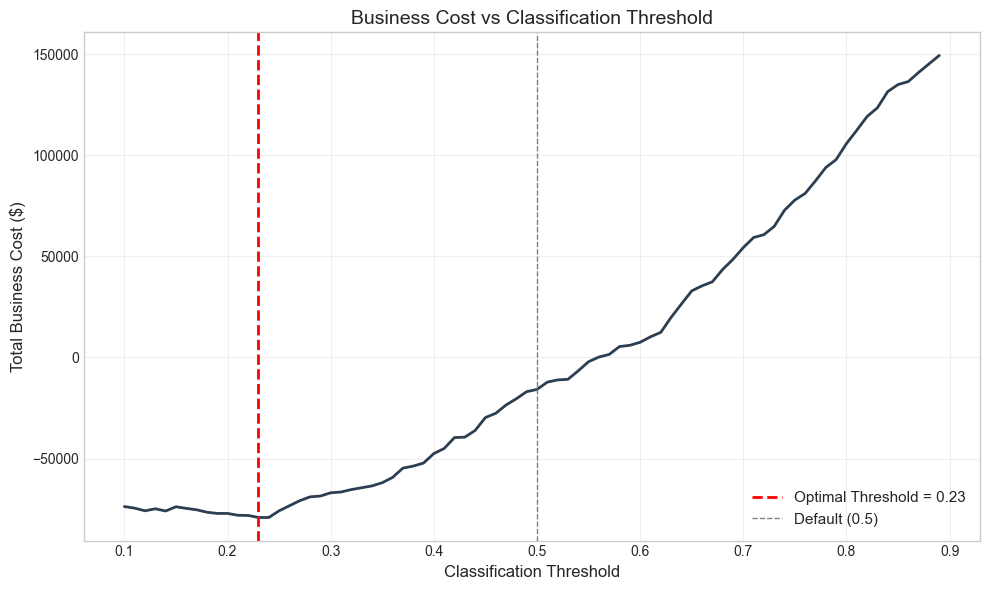

Optimal Threshold: 0.23
Business Cost at optimal: $-79,100
Business Cost at default (0.5): $-15,800


In [119]:
# Business cost assumptions (in dollars)
# These values should be calibrated with actual business data
cost_fn = 500   # Cost of missing a churner
cost_fp = 100   # Cost of false alarm (retention offer to non-churner)
cost_tp = -400  # Benefit of catching a churner (saved revenue minus retention cost)
cost_tn = 0     # No action needed

fpr_vals, tpr_vals, thresholds_roc = roc_curve(y_test, rf_prob)

best_threshold = 0.5
min_cost = float('inf')
threshold_results = []

for threshold in np.arange(0.1, 0.9, 0.01):
    pred_at_threshold = (rf_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_at_threshold).ravel()
    
    total_cost = (fn * cost_fn) + (fp * cost_fp) + (tp * cost_tp) + (tn * cost_tn)
    threshold_results.append({'Threshold': threshold, 'Cost': total_cost, 
                              'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn})
    
    if total_cost < min_cost:
        min_cost = total_cost
        best_threshold = threshold

threshold_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(10, 6))
plt.plot(threshold_df['Threshold'], threshold_df['Cost'], linewidth=2, color='#2c3e50')
plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Optimal Threshold = {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Default (0.5)')
plt.xlabel('Classification Threshold', fontsize=12)
plt.ylabel('Total Business Cost ($)', fontsize=12)
plt.title('Business Cost vs Classification Threshold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Business Cost at optimal: ${min_cost:,.0f}")
print(f"Business Cost at default (0.5): ${threshold_df[threshold_df['Threshold'].round(2)==0.50]['Cost'].values[0]:,.0f}")

### 11.3 Performance at Optimal Threshold

In [120]:
pred_optimal = (rf_prob >= best_threshold).astype(int)

print(f"PERFORMANCE AT OPTIMAL THRESHOLD ({best_threshold:.2f}) vs DEFAULT (0.50)")
print("=" * 60)
print(f"{'Metric':<20}{'Default (0.50)':<20}{'Optimal ({:.2f})'.format(best_threshold)}")
print("-" * 60)
print(f"{'Accuracy':<20}{accuracy_score(y_test, rf_pred):<20.4f}{accuracy_score(y_test, pred_optimal):.4f}")
print(f"{'Precision':<20}{precision_score(y_test, rf_pred):<20.4f}{precision_score(y_test, pred_optimal):.4f}")
print(f"{'Recall':<20}{recall_score(y_test, rf_pred):<20.4f}{recall_score(y_test, pred_optimal):.4f}")
print(f"{'F1-Score':<20}{f1_score(y_test, rf_pred):<20.4f}{f1_score(y_test, pred_optimal):.4f}")
print("=" * 60)
print(f"\nAt the optimal threshold, we catch more churners (higher Recall)")
print(f"  at an acceptable trade-off in Precision.")

PERFORMANCE AT OPTIMAL THRESHOLD (0.23) vs DEFAULT (0.50)
Metric              Default (0.50)      Optimal (0.23)
------------------------------------------------------------
Accuracy            0.7715              0.6643
Precision           0.5588              0.4373
Recall              0.6604              0.9225
F1-Score            0.6054              0.5933

At the optimal threshold, we catch more churners (higher Recall)
  at an acceptable trade-off in Precision.
